<a href="https://colab.research.google.com/github/avxsharma-glitch/Python-Libraries/blob/main/Analysis_Script_(Binder).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Correlation Coefficient between Transit Time and Rating: -0.87


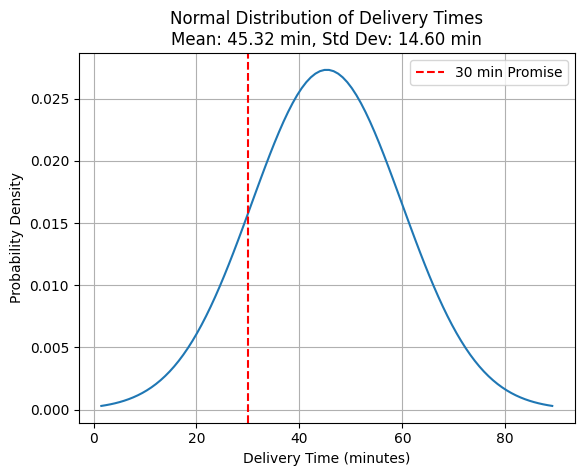


--- Summary Statistics for Report ---
Average Delivery Time: 45.32 minutes
Standard Deviation: 14.60 minutes
Interpretation: A high standard deviation indicates inconsistent service.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# --- 1. SIMULATE DATA (Since we need data to analyze) ---
np.random.seed(42)
num_orders = 1000

# Transit Time (Simulated: Avg 45 mins, Std Dev 15)
transit_times = np.random.normal(45, 15, num_orders)
transit_times = np.clip(transit_times, 10, 120) # No negative times

# Customer Rating (Correlated negatively with time)
# Rating = 6 - (0.08 * time) + noise
ratings = 6 - (0.08 * transit_times) + np.random.normal(0, 0.5, num_orders)
ratings = np.clip(ratings, 1, 5).round()

df = pd.DataFrame({
    'Transit_Time': transit_times,
    'Rating': ratings
})

# --- 2. HYPOTHESIS TESTING (Phase 3 of Handout) ---

# Calculate Correlation
correlation = df['Transit_Time'].corr(df['Rating'])
print(f"Correlation Coefficient between Transit Time and Rating: {correlation:.2f}")

# --- 3. NORMAL DISTRIBUTION PLOT (GeoGebra Task Simulation) ---
# This simulates what you would see in GeoGebra

mu = df['Transit_Time'].mean()
sigma = df['Transit_Time'].std()

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.title(f"Normal Distribution of Delivery Times\nMean: {mu:.2f} min, Std Dev: {sigma:.2f} min")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.axvline(x=30, color='r', linestyle='--', label='30 min Promise')
plt.legend()
plt.show()

# --- 4. OUTPUT FOR FLOURISH/REPORT ---
print("\n--- Summary Statistics for Report ---")
print(f"Average Delivery Time: {mu:.2f} minutes")
print(f"Standard Deviation: {sigma:.2f} minutes")
print("Interpretation: A high standard deviation indicates inconsistent service.")